# Kalman Filter State-Space Model for Intraday Volume Forecasting

This notebook walks through the implementation of the Kalman filter volume model
from Chen, Feng, and Palomar (2016). The model decomposes log-volume into three
additive components:
- **eta_t**: daily average level (AR(1) across days, constant within a day)
- **phi_i**: intraday seasonal pattern (U-shaped, shared across days)
- **mu_{t,i}**: intraday dynamic residual (AR(1) bin-to-bin)

Parameters are estimated via the EM algorithm (Kalman filter + RTS smoother + closed-form M-step).
A robust variant adds Lasso-penalized sparse noise detection for automatic outlier handling.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path(".").resolve()))
from kalman_volume import KalmanVolumeModel, KalmanVolumeParams, compute_mape, rolling_mean_baseline

DATA_DIR = Path("../../../data/direction_7/prepared")

# Load metadata
with open(DATA_DIR / "metadata.json") as f:
    meta = json.load(f)
print(f"Tickers: {meta['tickers']}")
print(f"Bins per day: {meta['bins_per_day']}")
print(f"Bin width: {meta['bin_width_minutes']} min")

Tickers: ['SPY', 'DIA', 'QQQ', 'AAPL', 'AMZN', 'GOOG', 'IBM', 'JPM', 'MSFT', 'XOM']
Bins per day: 26
Bin width: 15 min


## 1. Load and Explore the Prepared Data

The data specialist has already prepared log-volume matrices (559 days x 26 bins)
normalized by ADV-60 (rolling 60-day average daily volume). Let's examine SPY as
the reference ticker.

Shape: 559 days x 26 bins
Date range: 2023-12-28 to 2026-03-31
Log-volume range: [-6.253, 0.756]
Mean: -3.595, Std: 0.742
All observed: True


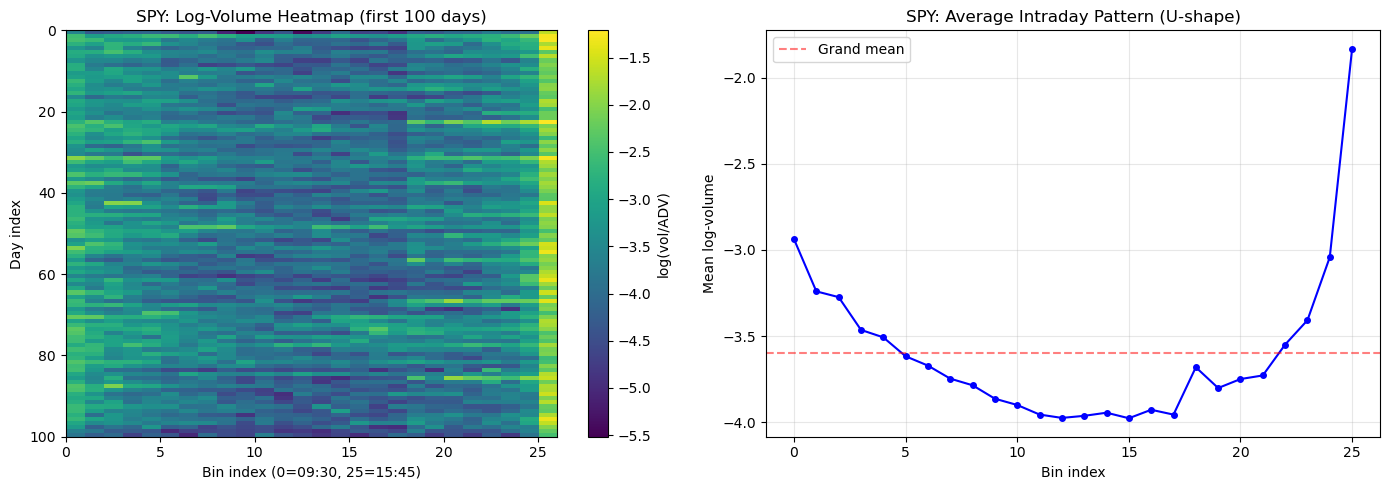

In [2]:
ticker = "SPY"
log_vol = pd.read_parquet(DATA_DIR / f"{ticker}_log_volume.parquet")
observed = pd.read_parquet(DATA_DIR / f"{ticker}_observed.parquet")
raw_vol = pd.read_parquet(DATA_DIR / f"{ticker}_raw_volume_15min.parquet")

y = log_vol.values
obs = observed.values.astype(bool)
T, I = y.shape

print(f"Shape: {T} days x {I} bins")
print(f"Date range: {log_vol.index[0]} to {log_vol.index[-1]}")
print(f"Log-volume range: [{y.min():.3f}, {y.max():.3f}]")
print(f"Mean: {y.mean():.3f}, Std: {y.std():.3f}")
print(f"All observed: {obs.all()}")

# Plot the raw log-volume heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(y[:100], aspect="auto", cmap="viridis",
                     extent=[0, I, 100, 0])
axes[0].set_xlabel("Bin index (0=09:30, 25=15:45)")
axes[0].set_ylabel("Day index")
axes[0].set_title(f"{ticker}: Log-Volume Heatmap (first 100 days)")
plt.colorbar(im, ax=axes[0], label="log(vol/ADV)")

# Average intraday pattern
avg_pattern = y.mean(axis=0)
axes[1].plot(avg_pattern, "b-o", markersize=4)
axes[1].set_xlabel("Bin index")
axes[1].set_ylabel("Mean log-volume")
axes[1].set_title(f"{ticker}: Average Intraday Pattern (U-shape)")
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y.mean(), color="r", linestyle="--", alpha=0.5, label="Grand mean")
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. EM Algorithm: Parameter Estimation

We fit the Kalman filter model via EM on the first 252 trading days (approximately 1 year).
The EM alternates between:
- **E-step**: Forward Kalman filter + backward RTS smoother to estimate hidden states
- **M-step**: Closed-form parameter updates from sufficient statistics

The log-likelihood should increase monotonically (guaranteed by Jensen's inequality).

EM iter   0: log-likelihood = -4066.5867
EM iter   1: log-likelihood = -3265.1354
EM iter   2: log-likelihood = -3050.2181
EM iter   3: log-likelihood = -2956.6409
EM iter   4: log-likelihood = -2912.7408
EM iter   5: log-likelihood = -2893.2306
EM iter   6: log-likelihood = -2884.8050
EM iter   7: log-likelihood = -2881.0519
EM iter   8: log-likelihood = -2879.2388
EM iter   9: log-likelihood = -2878.2610
EM iter  10: log-likelihood = -2877.6702
EM iter  11: log-likelihood = -2877.2768
EM iter  12: log-likelihood = -2876.9944
EM iter  13: log-likelihood = -2876.7802
EM iter  14: log-likelihood = -2876.6107
EM iter  15: log-likelihood = -2876.4724
EM iter  16: log-likelihood = -2876.3567
EM iter  17: log-likelihood = -2876.2580
EM iter  18: log-likelihood = -2876.1724
EM iter  19: log-likelihood = -2876.0973
EM iter  20: log-likelihood = -2876.0306
EM iter  21: log-likelihood = -2875.9709
EM iter  22: log-likelihood = -2875.9171
EM iter  23: log-likelihood = -2875.8683
EM iter  24: log

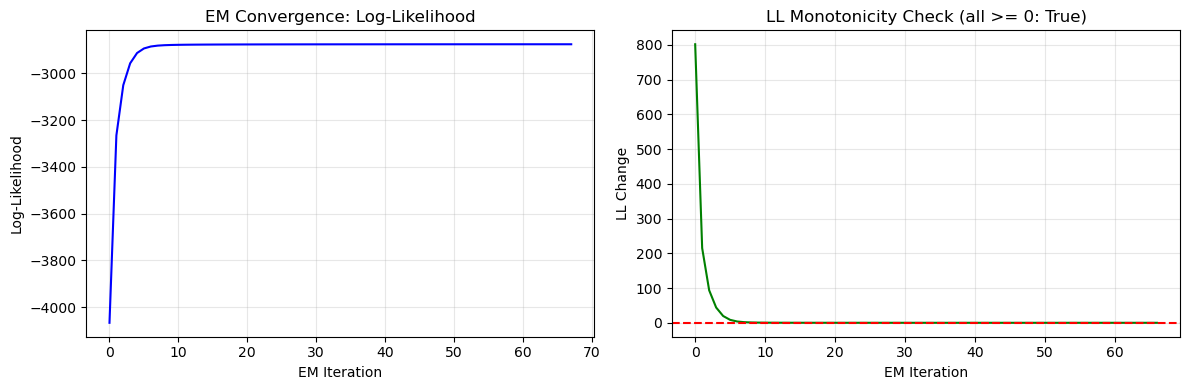

In [3]:
train_days = 252
y_train = y[:train_days]
obs_train = obs[:train_days]

# Fit standard Kalman filter model
model = KalmanVolumeModel(bins_per_day=I, robust=False)
result = model.fit(y_train, obs_train, max_iter=100, epsilon=1e-6, verbose=True)

p = result["params"]
print(f"\nConverged parameters:")
print(f"  a_eta (daily AR):     {p.a_eta:.6f}  (expect close to 1)")
print(f"  a_mu  (intraday AR):  {p.a_mu:.6f}")
print(f"  sigma_eta^2:          {p.sigma_eta_sq:.6f}")
print(f"  sigma_mu^2:           {p.sigma_mu_sq:.6f}")
print(f"  r (obs noise var):    {p.r:.6f}")

# Plot EM convergence
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ll = result["log_likelihood_history"]
axes[0].plot(ll, "b-")
axes[0].set_xlabel("EM Iteration")
axes[0].set_ylabel("Log-Likelihood")
axes[0].set_title("EM Convergence: Log-Likelihood")
axes[0].grid(True, alpha=0.3)

# Verify monotonicity
diffs = np.diff(ll)
axes[1].plot(diffs, "g-")
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("EM Iteration")
axes[1].set_ylabel("LL Change")
axes[1].set_title(f"LL Monotonicity Check (all >= 0: {np.all(diffs >= -1e-6)})")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Estimated Seasonality (phi)

The seasonal component phi should show the well-known U-shaped intraday volume pattern:
high volume at market open and close, low volume mid-day.

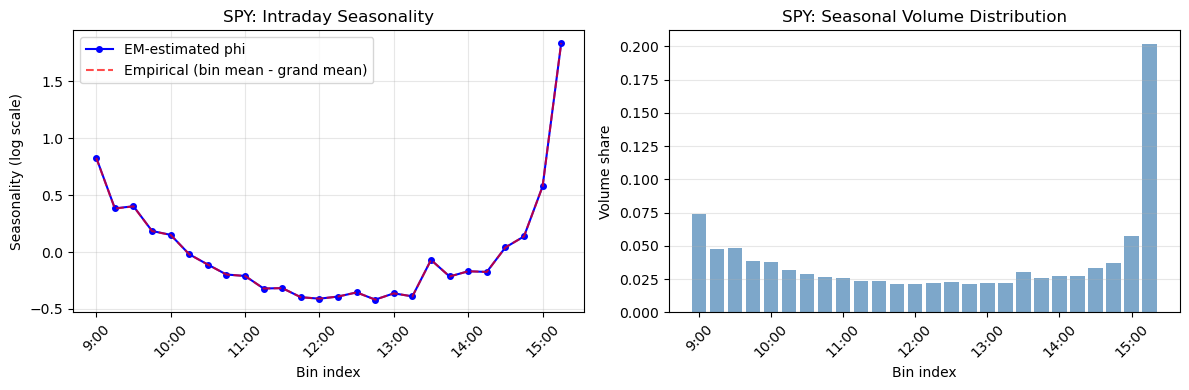

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# EM-estimated phi vs empirical mean
bin_labels = [f"{9+i*15//60}:{i*15%60:02d}" for i in range(I)]
axes[0].plot(p.phi, "b-o", markersize=4, label="EM-estimated phi")
axes[0].plot(y_train.mean(axis=0) - y_train.mean(), "r--", alpha=0.7,
             label="Empirical (bin mean - grand mean)")
axes[0].set_xlabel("Bin index")
axes[0].set_ylabel("Seasonality (log scale)")
axes[0].set_title(f"{ticker}: Intraday Seasonality")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, I, 4))
axes[0].set_xticklabels([bin_labels[i] for i in range(0, I, 4)], rotation=45)

# Convert to linear scale (volume proportion)
vol_seasonal = np.exp(p.phi)
vol_weights = vol_seasonal / vol_seasonal.sum()
axes[1].bar(range(I), vol_weights, color="steelblue", alpha=0.7)
axes[1].set_xlabel("Bin index")
axes[1].set_ylabel("Volume share")
axes[1].set_title(f"{ticker}: Seasonal Volume Distribution")
axes[1].set_xticks(range(0, I, 4))
axes[1].set_xticklabels([bin_labels[i] for i in range(0, I, 4)], rotation=45)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 4. Kalman Filter State Decomposition

Run the Kalman filter on the full dataset to see how the hidden states
(daily level eta and intraday dynamic mu) evolve over time.

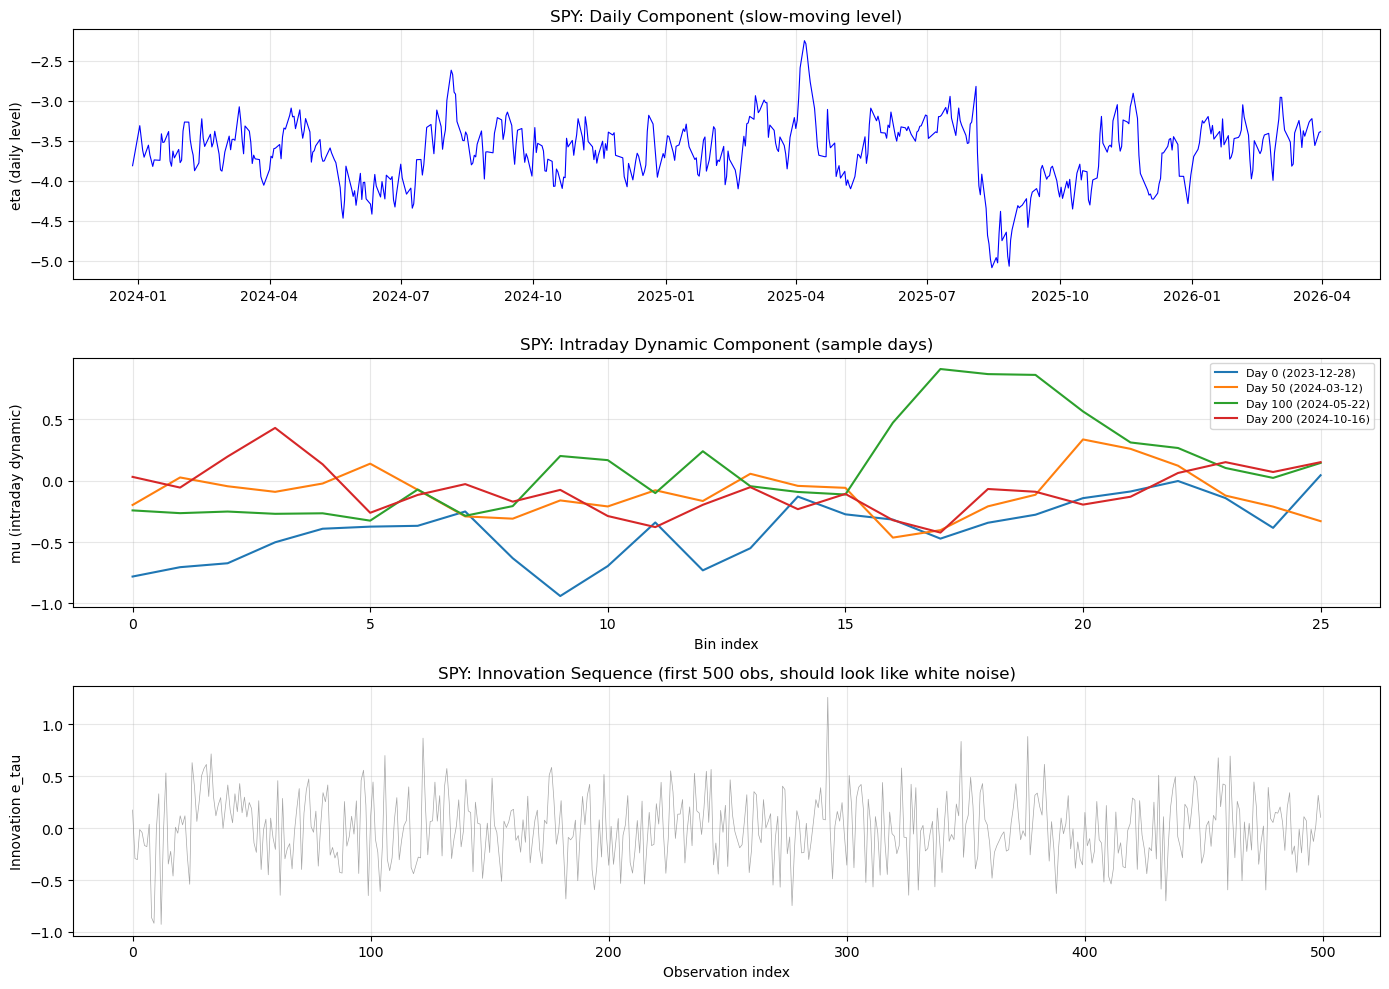

Innovation autocorrelation (should be near zero for lags > 0):
  Lag  1: 0.0385
  Lag  2: -0.0110
  Lag  5: -0.0072
  Lag 10: 0.0298
  Lag 20: 0.0126


In [5]:
# Run filter on full dataset with trained parameters
filtered = model.kalman_filter(y, obs, p)
x_filt = filtered["x_filt"]
y_hat = filtered["y_hat"].reshape(T, I)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Daily component eta (one value per day = first bin of each day)
day_indices = np.arange(0, T * I, I)
eta_daily = x_filt[day_indices, 0]
axes[0].plot(log_vol.index, eta_daily, "b-", linewidth=0.8)
axes[0].set_ylabel("eta (daily level)")
axes[0].set_title(f"{ticker}: Daily Component (slow-moving level)")
axes[0].grid(True, alpha=0.3)

# Intraday dynamic mu for a few sample days
sample_days = [0, 50, 100, 200]
for d in sample_days:
    mu_day = x_filt[d*I:(d+1)*I, 1]
    axes[1].plot(mu_day, label=f"Day {d} ({log_vol.index[d]})")
axes[1].set_xlabel("Bin index")
axes[1].set_ylabel("mu (intraday dynamic)")
axes[1].set_title(f"{ticker}: Intraday Dynamic Component (sample days)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Innovation sequence (should be white noise)
e = filtered["e"]
obs_flat = obs.ravel()
e_obs = e[obs_flat]
axes[2].plot(e_obs[:500], "gray", linewidth=0.5, alpha=0.7)
axes[2].set_xlabel("Observation index")
axes[2].set_ylabel("Innovation e_tau")
axes[2].set_title(f"{ticker}: Innovation Sequence (first 500 obs, should look like white noise)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Innovation autocorrelation check
from numpy.fft import fft, ifft
def acf(x, nlags=20):
    n = len(x)
    x_centered = x - x.mean()
    c0 = np.sum(x_centered**2)
    return np.array([np.sum(x_centered[:n-k]*x_centered[k:])/c0 for k in range(nlags+1)])

ac = acf(e_obs, nlags=20)
print("Innovation autocorrelation (should be near zero for lags > 0):")
for lag in [1, 2, 5, 10, 20]:
    print(f"  Lag {lag:2d}: {ac[lag]:.4f}")

## 5. Out-of-Sample Prediction Performance

Compare the Kalman filter's dynamic (one-step-ahead) forecasts against the
rolling mean baseline. The paper reports ~46% average MAPE for the KF and
~65% for rolling mean (64% improvement).

Out-of-sample results (SPY, 307 days):
  Kalman Filter MAPE: 0.2802 (28.0%)
  Rolling Mean MAPE:  0.5767 (57.7%)
  Improvement:        51.4%


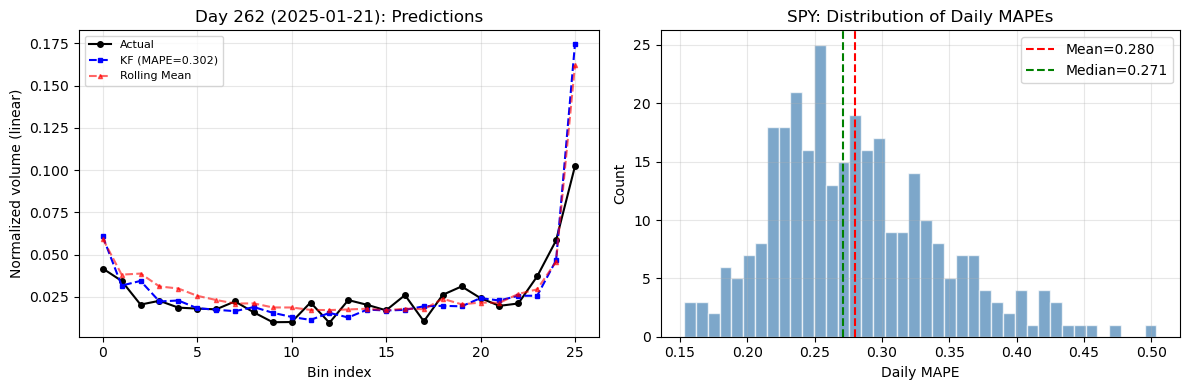

In [6]:
# OOS evaluation
oos_y = y[train_days:]
oos_yhat = y_hat[train_days:]
oos_obs = obs[train_days:]

kf_mape = compute_mape(oos_y, oos_yhat, oos_obs)

rm = rolling_mean_baseline(y, obs, train_days)
rm_oos = rm[train_days:]
rm_mask = oos_obs & ~np.isnan(rm_oos)
rm_mape = compute_mape(oos_y, rm_oos, rm_mask)

improvement = (1 - kf_mape / rm_mape) * 100

print(f"Out-of-sample results ({ticker}, {T - train_days} days):")
print(f"  Kalman Filter MAPE: {kf_mape:.4f} ({kf_mape*100:.1f}%)")
print(f"  Rolling Mean MAPE:  {rm_mape:.4f} ({rm_mape*100:.1f}%)")
print(f"  Improvement:        {improvement:.1f}%")

# Plot actual vs predicted for a sample OOS day
sample_day = train_days + 10
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

actual_lin = np.exp(y[sample_day])
pred_lin = np.exp(y_hat[sample_day])
rm_lin = np.exp(rm[sample_day]) if not np.any(np.isnan(rm[sample_day])) else None

axes[0].plot(actual_lin, "k-o", markersize=4, label="Actual")
axes[0].plot(pred_lin, "b--s", markersize=3, label=f"KF (MAPE={compute_mape(y[sample_day:sample_day+1], y_hat[sample_day:sample_day+1], obs[sample_day:sample_day+1]):.3f})")
if rm_lin is not None:
    axes[0].plot(rm_lin, "r--^", markersize=3, alpha=0.6, label="Rolling Mean")
axes[0].set_xlabel("Bin index")
axes[0].set_ylabel("Normalized volume (linear)")
axes[0].set_title(f"Day {sample_day} ({log_vol.index[sample_day]}): Predictions")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Distribution of per-day MAPEs
daily_mapes = []
for d in range(train_days, T):
    dm = compute_mape(y[d:d+1], y_hat[d:d+1], obs[d:d+1])
    daily_mapes.append(dm)

axes[1].hist(daily_mapes, bins=40, color="steelblue", alpha=0.7, edgecolor="white")
axes[1].axvline(np.mean(daily_mapes), color="r", linestyle="--", label=f"Mean={np.mean(daily_mapes):.3f}")
axes[1].axvline(np.median(daily_mapes), color="g", linestyle="--", label=f"Median={np.median(daily_mapes):.3f}")
axes[1].set_xlabel("Daily MAPE")
axes[1].set_ylabel("Count")
axes[1].set_title(f"{ticker}: Distribution of Daily MAPEs")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Robust Filter: Outlier Detection

The robust variant adds Lasso-penalized sparse noise detection. When an innovation
exceeds the threshold (lambda * S_tau / 2), the excess is attributed to an outlier
component z_star rather than being absorbed into the state estimate.

Standard r estimate: 0.0648
Effective lambda (k=3.0): 23.58

Robust model parameters:
  a_eta=0.998125, a_mu=0.736725, r=0.064558
  Outliers detected: 13/14534 (0.09%)


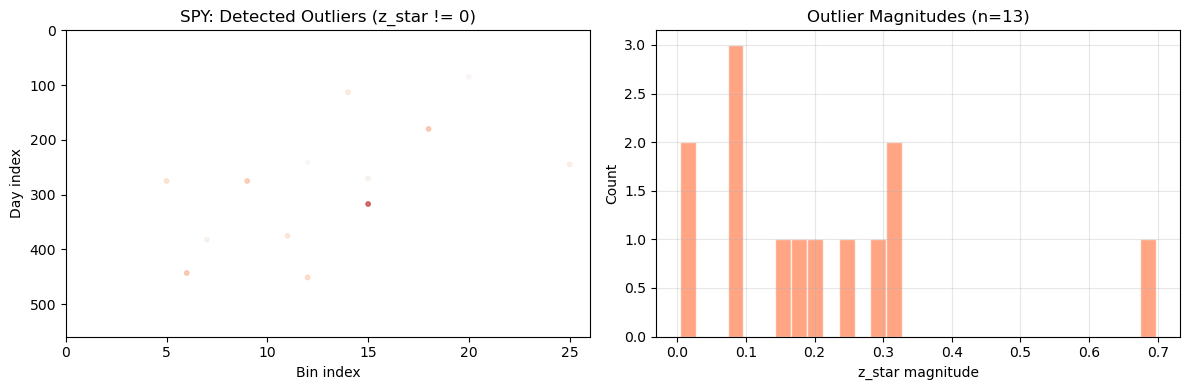

In [7]:
# Fit robust model with properly scaled lambda
# lambda = 2*k/sqrt(r) where k is the outlier threshold in std devs
k = 3.0  # 3-sigma threshold
eff_lambda = 2 * k / np.sqrt(p.r)
print(f"Standard r estimate: {p.r:.4f}")
print(f"Effective lambda (k={k}): {eff_lambda:.2f}")

model_r = KalmanVolumeModel(bins_per_day=I, robust=True, lam=eff_lambda)
result_r = model_r.fit(y_train, obs_train, max_iter=100, epsilon=1e-6, verbose=False)
pr = result_r["params"]

# Run on full data
filtered_r = model_r.kalman_filter(y, obs, pr)
z_star = filtered_r["z_star"]
n_outliers = np.sum(z_star != 0)
n_total = len(z_star)
print(f"\nRobust model parameters:")
print(f"  a_eta={pr.a_eta:.6f}, a_mu={pr.a_mu:.6f}, r={pr.r:.6f}")
print(f"  Outliers detected: {n_outliers}/{n_total} ({100*n_outliers/n_total:.2f}%)")

# Plot outlier locations
z_mat = z_star.reshape(T, I)
outlier_days, outlier_bins = np.where(z_mat != 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(outlier_bins, outlier_days, c=z_mat[z_mat != 0],
               cmap="RdBu_r", s=10, alpha=0.7, vmin=-1, vmax=1)
axes[0].set_xlabel("Bin index")
axes[0].set_ylabel("Day index")
axes[0].set_title(f"{ticker}: Detected Outliers (z_star != 0)")
axes[0].set_xlim(0, I)
axes[0].set_ylim(T, 0)

# Distribution of outlier magnitudes
z_nz = z_star[z_star != 0]
if len(z_nz) > 0:
    axes[1].hist(z_nz, bins=30, color="coral", alpha=0.7, edgecolor="white")
    axes[1].set_xlabel("z_star magnitude")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Outlier Magnitudes (n={len(z_nz)})")
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Full Results Summary

Load the results from the full pipeline run (all 10 tickers with rolling-window
re-estimation) to see the cross-sectional performance.

In [8]:
# Load full pipeline results (produced by run_model.py)
results_file = Path("results.json")
if results_file.exists():
    with open(results_file) as f:
        all_results = json.load(f)

    print(f"{'Ticker':<8} {'Dyn MAPE':>10} {'Stat MAPE':>10} {'RM MAPE':>10} "
          f"{'Improv%':>8} {'Dyn TE':>8}")
    print("-" * 60)
    for r in all_results:
        print(f"{r['ticker']:<8} {r['dynamic_mape']:>10.4f} {r['static_mape']:>10.4f} "
              f"{r['rm_mape']:>10.4f} {r['improvement_pct']:>8.1f} "
              f"{r['dynamic_te_bps']:>8.2f}")
    print("-" * 60)
    avg_dyn = np.mean([r["dynamic_mape"] for r in all_results])
    avg_stat = np.mean([r["static_mape"] for r in all_results])
    avg_rm = np.mean([r["rm_mape"] for r in all_results])
    avg_imp = np.mean([r["improvement_pct"] for r in all_results])
    avg_dte = np.mean([r["dynamic_te_bps"] for r in all_results])
    print(f"{'Average':<8} {avg_dyn:>10.4f} {avg_stat:>10.4f} {avg_rm:>10.4f} "
          f"{avg_imp:>8.1f} {avg_dte:>8.2f}")
else:
    print("Results file not found. Run run_model.py first.")

Ticker     Dyn MAPE  Stat MAPE    RM MAPE  Improv%   Dyn TE
------------------------------------------------------------
SPY          0.2771     0.4145     0.5767     51.9  1409.89
DIA          0.5423     0.7592     0.8282     34.5  2196.07
QQQ          0.2841     0.4206     0.4126     31.1  1326.66
AAPL         0.2714     0.4137     0.4536     40.2  1365.26
AMZN         0.2661     0.4031     0.4616     42.4  1311.32
GOOG         0.3092     0.4555     0.5594     44.7  1539.12
IBM          0.3817     0.6035     0.6330     39.7  1698.87
JPM          0.3066     0.4539     0.4834     36.6  1417.55
MSFT         0.3025     0.4440     0.4921     38.5  1479.83
XOM          0.2788     0.3855     0.3735     25.4  1324.73
------------------------------------------------------------
Average      0.3220     0.4753     0.5274     38.5  1506.93
